In [1]:
import matplotlib.pyplot as plt
import xarray as xr

path = "/import/beegfs/CMIP6/wrf_era5/04km/invar/elevation_4km.nc"
ds = xr.open_dataset(path)
print(ds)

# sanity check the min and max elevations

da = ds.elevation

print(f"  Min: {float(da.min()):.2f}")
print(f"  Max: {float(da.max()):.2f}")

# interesting that the max elevation is ~5000 m
# Denali is 6190 m, Bona, Foraker, Elias all above 5000 m
# and unlike ASTER GDEM, there are no negative elevations 

<xarray.Dataset> Size: 2MB
Dimensions:    (south_north: 450, west_east: 420)
Coordinates:
    XLAT       (south_north, west_east) float32 756kB ...
    XLONG      (south_north, west_east) float32 756kB ...
Dimensions without coordinates: south_north, west_east
Data variables:
    elevation  (south_north, west_east) float32 756kB ...
  Min: 0.00
  Max: 4996.77


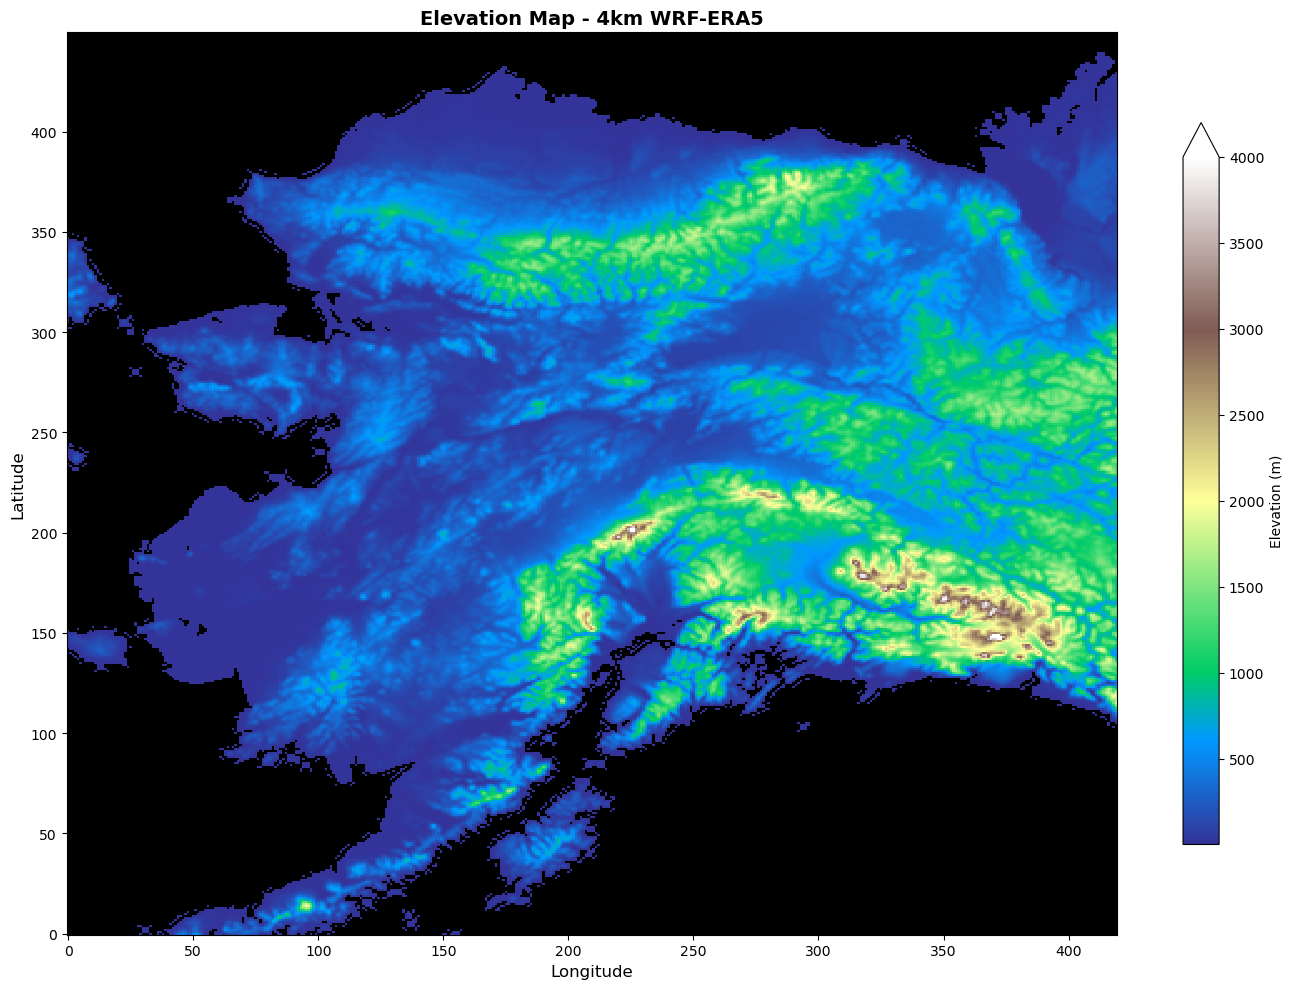

In [2]:
fig, ax = plt.subplots(figsize=(14, 10))

# Create the plot
im = da.plot(ax=ax, cmap='terrain', robust=True, 
                   cbar_kwargs={'label': 'Elevation (m)', 'shrink': 0.8})

ax.set_title(f'Elevation Map - 4km WRF-ERA5', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
# expand the colorbar range to better show the elevation distribution
im.set_clim(0.01, 4000)
# elevation less than 0.01 is black
im.cmap.set_under('black')
plt.tight_layout()
plt.show()

In [3]:
curated_path = "/beegfs/CMIP6/cparr4/daily_downscaled_era5_for_rasdaman/elevation_grid_4km.nc"

curated_ds = xr.open_dataset(curated_path)
# sanity check the min and max elevations

print(curated_ds)

da = curated_ds.elevation

print(f"  Min: {float(da.min()):.2f}")
print(f"  Max: {float(da.max()):.2f}")

# great, no change of value during regridding


<xarray.Dataset> Size: 821kB
Dimensions:      (x: 442, y: 460)
Coordinates:
  * x            (x) float64 4kB -8.266e+05 -8.226e+05 ... 9.364e+05 9.404e+05
  * y            (y) float64 4kB 2.465e+06 2.461e+06 ... 6.299e+05 6.259e+05
Data variables:
    spatial_ref  int64 8B ...
    elevation    (y, x) float32 813kB ...
  Min: 0.00
  Max: 4996.77


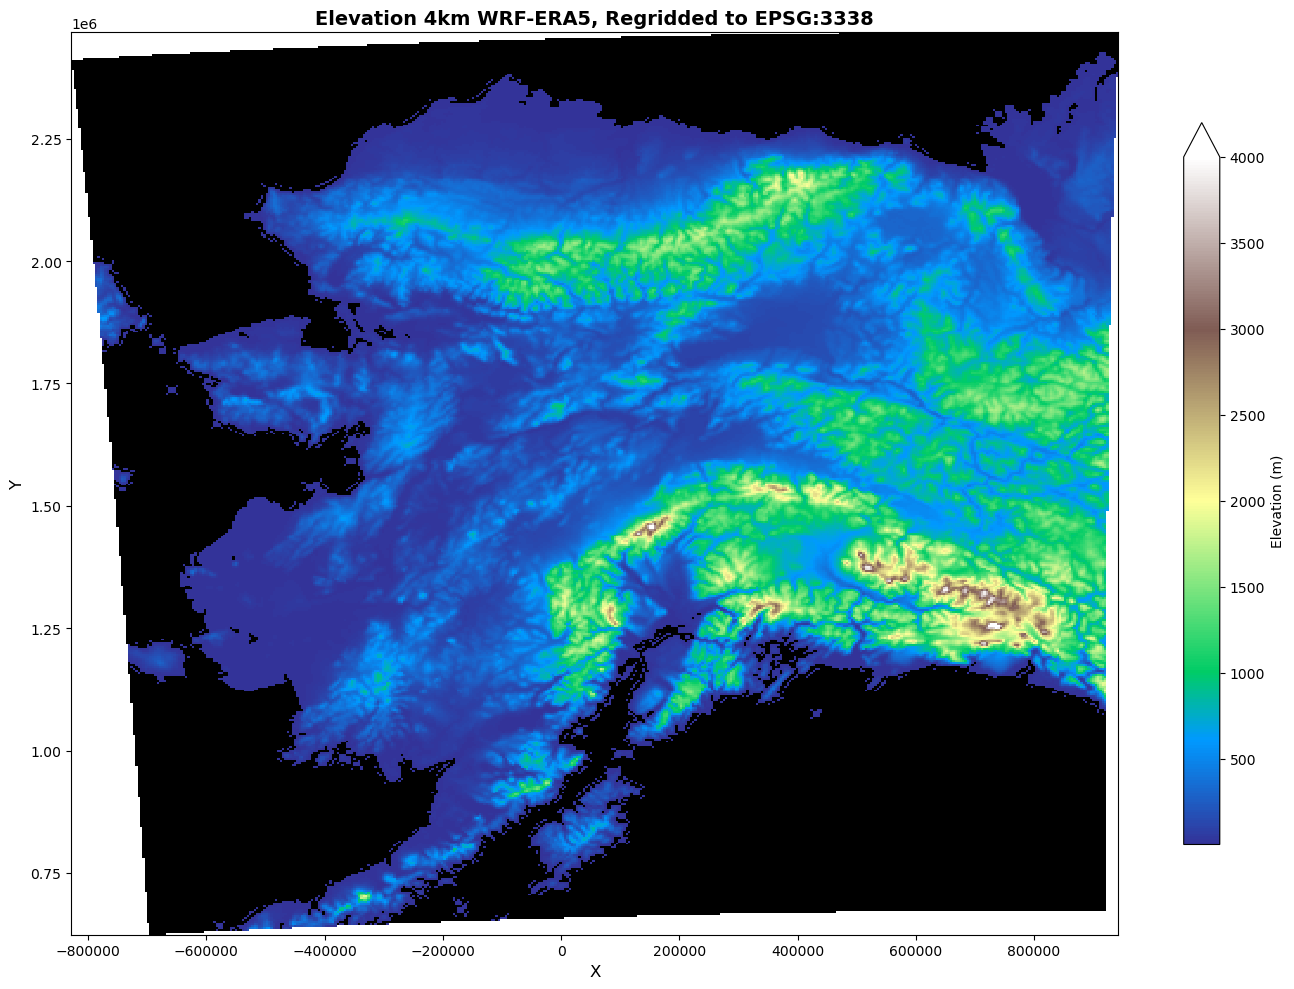

In [4]:
fig, ax = plt.subplots(figsize=(14, 10))

# Create the plot
im = da.plot(ax=ax, cmap='terrain', robust=True, 
                   cbar_kwargs={'label': 'Elevation (m)', 'shrink': 0.8})

ax.set_title(f'Elevation 4km WRF-ERA5, Regridded to EPSG:3338', fontsize=14, fontweight='bold')
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
# expand the colorbar range to better show the elevation distribution
im.set_clim(0.01, 4000)
# elevation less than 0.01 is black
im.cmap.set_under('black')
plt.tight_layout()
plt.show()
